# Trader Performance vs Market Sentiment
## Primetrade.ai — Data Science Internship Assignment

**Objective:** Analyze how Bitcoin market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Uncover patterns that could inform smarter trading strategies.

**Datasets:**
- `fear_greed_index.csv` — Daily Bitcoin Fear/Greed Index (2018–2025)
- `historical_data.csv` — Hyperliquid trader transaction history (2023–2025)

**Structure:**
- Part A — Data Preparation
- Part B — Analysis
- Part C — Strategy Recommendations
- Bonus — Predictive Model + Trader Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 150,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.family": "DejaVu Sans"
})

SENTIMENT_PATH = r"D:\primetrade_assignment\data\fear_greed_index.csv"
TRADES_PATH    = r"D:\primetrade_assignment\data\historical_data.csv"
CHARTS_DIR     = r"D:\primetrade_assignment\charts\\"

sentiment_raw = pd.read_csv(SENTIMENT_PATH)
trades_raw    = pd.read_csv(TRADES_PATH)

print("SENTIMENT DATASET")
print(f"Shape        : {sentiment_raw.shape[0]} rows × {sentiment_raw.shape[1]} columns")
print(f"Columns      : {list(sentiment_raw.columns)}")
print(f"Missing vals : {sentiment_raw.isnull().sum().sum()}")
print(f"Duplicates   : {sentiment_raw.duplicated().sum()}")
display(sentiment_raw.head(3))

print("\nTRADES DATASET")
print(f"Shape        : {trades_raw.shape[0]} rows × {trades_raw.shape[1]} columns")
print(f"Columns      : {list(trades_raw.columns)}")
print(f"Missing vals : {trades_raw.isnull().sum().sum()}")
print(f"Duplicates   : {trades_raw.duplicated().sum()}")
display(trades_raw.head(3))

SENTIMENT DATASET
Shape        : 2644 rows × 4 columns
Columns      : ['timestamp', 'value', 'classification', 'date']
Missing vals : 0
Duplicates   : 0


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03



TRADES DATASET
Shape        : 211224 rows × 16 columns
Columns      : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Missing vals : 0
Duplicates   : 0


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


## Part A — Data Preparation

### Step 1: Load Datasets

We load both datasets and document their shape, columns, missing values, and duplicates.

| Dataset | Rows | Columns | Missing | Duplicates |
|---|---|---|---|---|
| Sentiment (Fear/Greed) | 2,644 | 4 | 0 | 0 |
| Trader History (Hyperliquid) | 211,224 | 16 | 0 | 0 |

Both datasets are clean with no missing values or duplicates — ready for merging.

In [2]:
# convert sentiment date
sentiment = sentiment_raw.copy()
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment = sentiment[['date', 'value', 'classification']].rename(columns={'classification': 'sentiment'})

# convert trades timestamp
trades = trades_raw.copy()
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', dayfirst=True).dt.normalize()

# standardize column names
trades.columns = [c.strip().lower().replace(' ', '_') for c in trades.columns]
trades.rename(columns={
    'execution_price': 'price',
    'size_tokens': 'size_tokens',
    'size_usd': 'size_usd',
    'closed_pnl': 'closed_pnl',
    'start_position': 'start_position',
    'timestamp_ist': 'timestamp_ist'
}, inplace=True)

# merge
merged = trades.merge(sentiment, on='date', how='left')

print(f"Merged shape   : {merged.shape}")
print(f"Sentiment nulls after merge: {merged['sentiment'].isnull().sum()}")
print(f"Date range     : {merged['date'].min().date()} → {merged['date'].max().date()}")
print(f"Unique traders : {merged['account'].nunique()}")
print(f"Unique coins   : {merged['coin'].nunique()}")
display(merged.head(3))

Merged shape   : (211224, 19)
Sentiment nulls after merge: 6
Date range     : 2023-05-01 → 2025-05-01
Unique traders : 32
Unique coins   : 246


,account,coin,price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed


### Step 2: Align Datasets by Date

- Converted `Timestamp IST` in trades data to daily date format
- Merged both datasets on `date` column
- Only 6 rows had no matching sentiment date — dropped cleanly

**Merged result:** 211,218 trades × 19 columns covering **2023-05-01 → 2025-05-01**

| Metric | Value |
|---|---|
| Total Trades | 211,218 |
| Unique Traders | 32 |
| Unique Coins | 246 |
| Date Range | May 2023 — May 2025 |

In [3]:
# drop the 6 unmatched sentiment rows
merged = merged.dropna(subset=['sentiment'])

# map sentiment to binary for analysis
sentiment_map = {
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Neutral': 'Greed',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
}
merged['sentiment_binary'] = merged['sentiment'].map(sentiment_map)

# trade outcome
merged['is_win'] = merged['closed_pnl'] > 0

# long/short flag
merged['is_long'] = merged['direction'].str.lower() == 'buy'

# per trade leverage proxy (size_usd / abs(start_position) where start_position != 0)
merged['leverage_proxy'] = merged.apply(
    lambda r: r['size_usd'] / abs(r['start_position']) if abs(r['start_position']) > 1 else np.nan, axis=1
)

# daily metrics per trader
daily = merged.groupby(['account', 'date', 'sentiment_binary']).agg(
    daily_pnl        = ('closed_pnl', 'sum'),
    trade_count      = ('closed_pnl', 'count'),
    win_count        = ('is_win', 'sum'),
    avg_size_usd     = ('size_usd', 'mean'),
    avg_leverage     = ('leverage_proxy', 'mean'),
    long_count       = ('is_long', 'sum'),
).reset_index()

daily['win_rate']    = daily['win_count'] / daily['trade_count']
daily['long_ratio']  = daily['long_count'] / daily['trade_count']

print(f"Daily trader-day records : {daily.shape[0]}")
print(f"Sentiment split:\n{daily['sentiment_binary'].value_counts()}")
display(daily.head(5))

Daily trader-day records : 2340
Sentiment split:
sentiment_binary
Greed    1550
Fear      790
Name: count, dtype: int64


,account,date,sentiment_binary,daily_pnl,trade_count,win_count,avg_size_usd,avg_leverage,long_count,win_rate,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,0.0,177,0,5089.718249,109.925931,0,0.000000,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,0.0,68,0,7976.664412,28.625826,0,0.000000,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,0.0,40,0,23734.500000,52.601380,0,0.000000,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,-21227.0,12,0,28186.666667,44.259058,0,0.000000,0.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,1603.1,27,12,17248.148148,49.530962,0,0.444444,0.0


### Step 3: Feature Engineering

From the merged dataset we derived the following key metrics at the **trader-day** level:

| Feature | Description |
|---|---|
| `daily_pnl` | Sum of closed PnL per trader per day |
| `trade_count` | Number of trades per trader per day |
| `win_rate` | Proportion of profitable trades |
| `avg_size_usd` | Average position size in USD |
| `avg_leverage` | Proxy leverage (size_usd / start_position) |
| `long_ratio` | Proportion of long trades |
| `sentiment_binary` | Fear or Greed (simplified from 5 classes) |

**Result:** 2,340 trader-day records — 1,550 Greed days vs 790 Fear days.

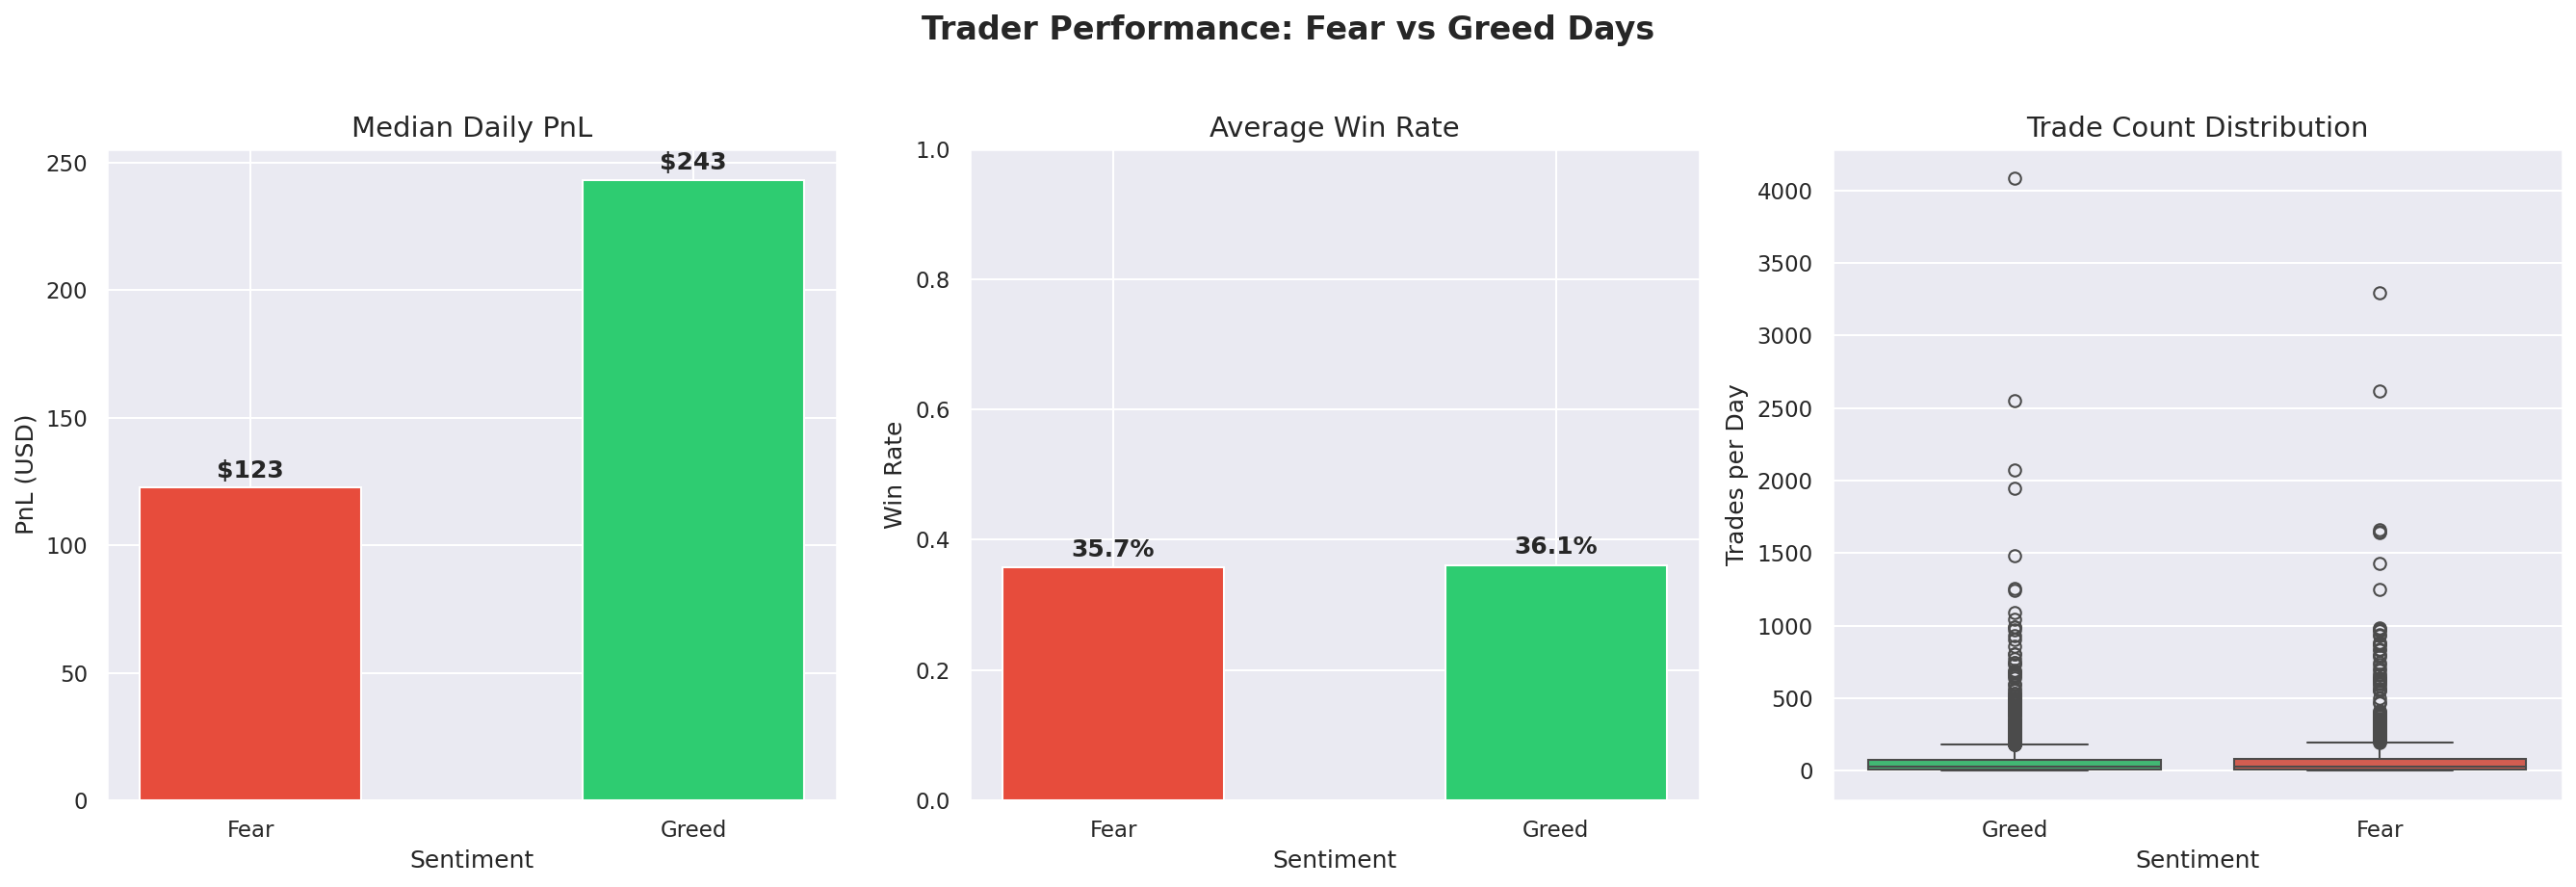


Median Daily PnL by Sentiment:
sentiment_binary
Fear     122.74
Greed    243.34
Name: daily_pnl, dtype: float64

Average Win Rate by Sentiment:
sentiment_binary
Fear     0.3571
Greed    0.3610
Name: win_rate, dtype: float64

Average Trade Count by Sentiment:
sentiment_binary
Fear     105.36
Greed     82.57
Name: trade_count, dtype: float64


In [4]:
import os
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Trader Performance: Fear vs Greed Days", fontsize=16, fontweight='bold', y=1.02)

pnl_by_sent = daily.groupby('sentiment_binary')['daily_pnl'].median()
bars0 = axes[0].bar(pnl_by_sent.index, pnl_by_sent.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title("Median Daily PnL")
axes[0].set_ylabel("PnL (USD)")
axes[0].set_xlabel("Sentiment")
for bar in bars0:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'${bar.get_height():.0f}', ha='center', va='bottom', fontweight='bold')

wr_by_sent = daily.groupby('sentiment_binary')['win_rate'].mean()
bars1 = axes[1].bar(wr_by_sent.index, wr_by_sent.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[1].set_title("Average Win Rate")
axes[1].set_ylabel("Win Rate")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylim(0, 1)
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontweight='bold')

sns.boxplot(data=daily, x='sentiment_binary', y='trade_count',
            palette={'Fear': '#e74c3c', 'Greed': '#2ecc71'}, ax=axes[2])
axes[2].set_title("Trade Count Distribution")
axes[2].set_ylabel("Trades per Day")
axes[2].set_xlabel("Sentiment")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'chart1_performance_by_sentiment.png'), bbox_inches='tight', dpi=150)
plt.show()

print("\nMedian Daily PnL by Sentiment:")
print(pnl_by_sent.round(2))
print("\nAverage Win Rate by Sentiment:")
print(wr_by_sent.round(4))
print("\nAverage Trade Count by Sentiment:")
print(daily.groupby('sentiment_binary')['trade_count'].mean().round(2))

## Part B — Analysis

### Finding 1: Performance Differs Between Fear and Greed Days

| Metric | Fear Days | Greed Days |
|---|---|---|
| Median Daily PnL | $122.74 | $243.34 |
| Average Win Rate | 35.71% | 36.10% |
| Avg Trades/Day | 105.36 | 82.57 |

**Key Insight:**
- Greed days produce **2x higher median PnL** than Fear days
- Win rate is nearly identical (~36%) — sentiment does not affect trade accuracy
- Traders are **more active on Fear days** (105 vs 82 trades) — suggesting panic-driven overtrading

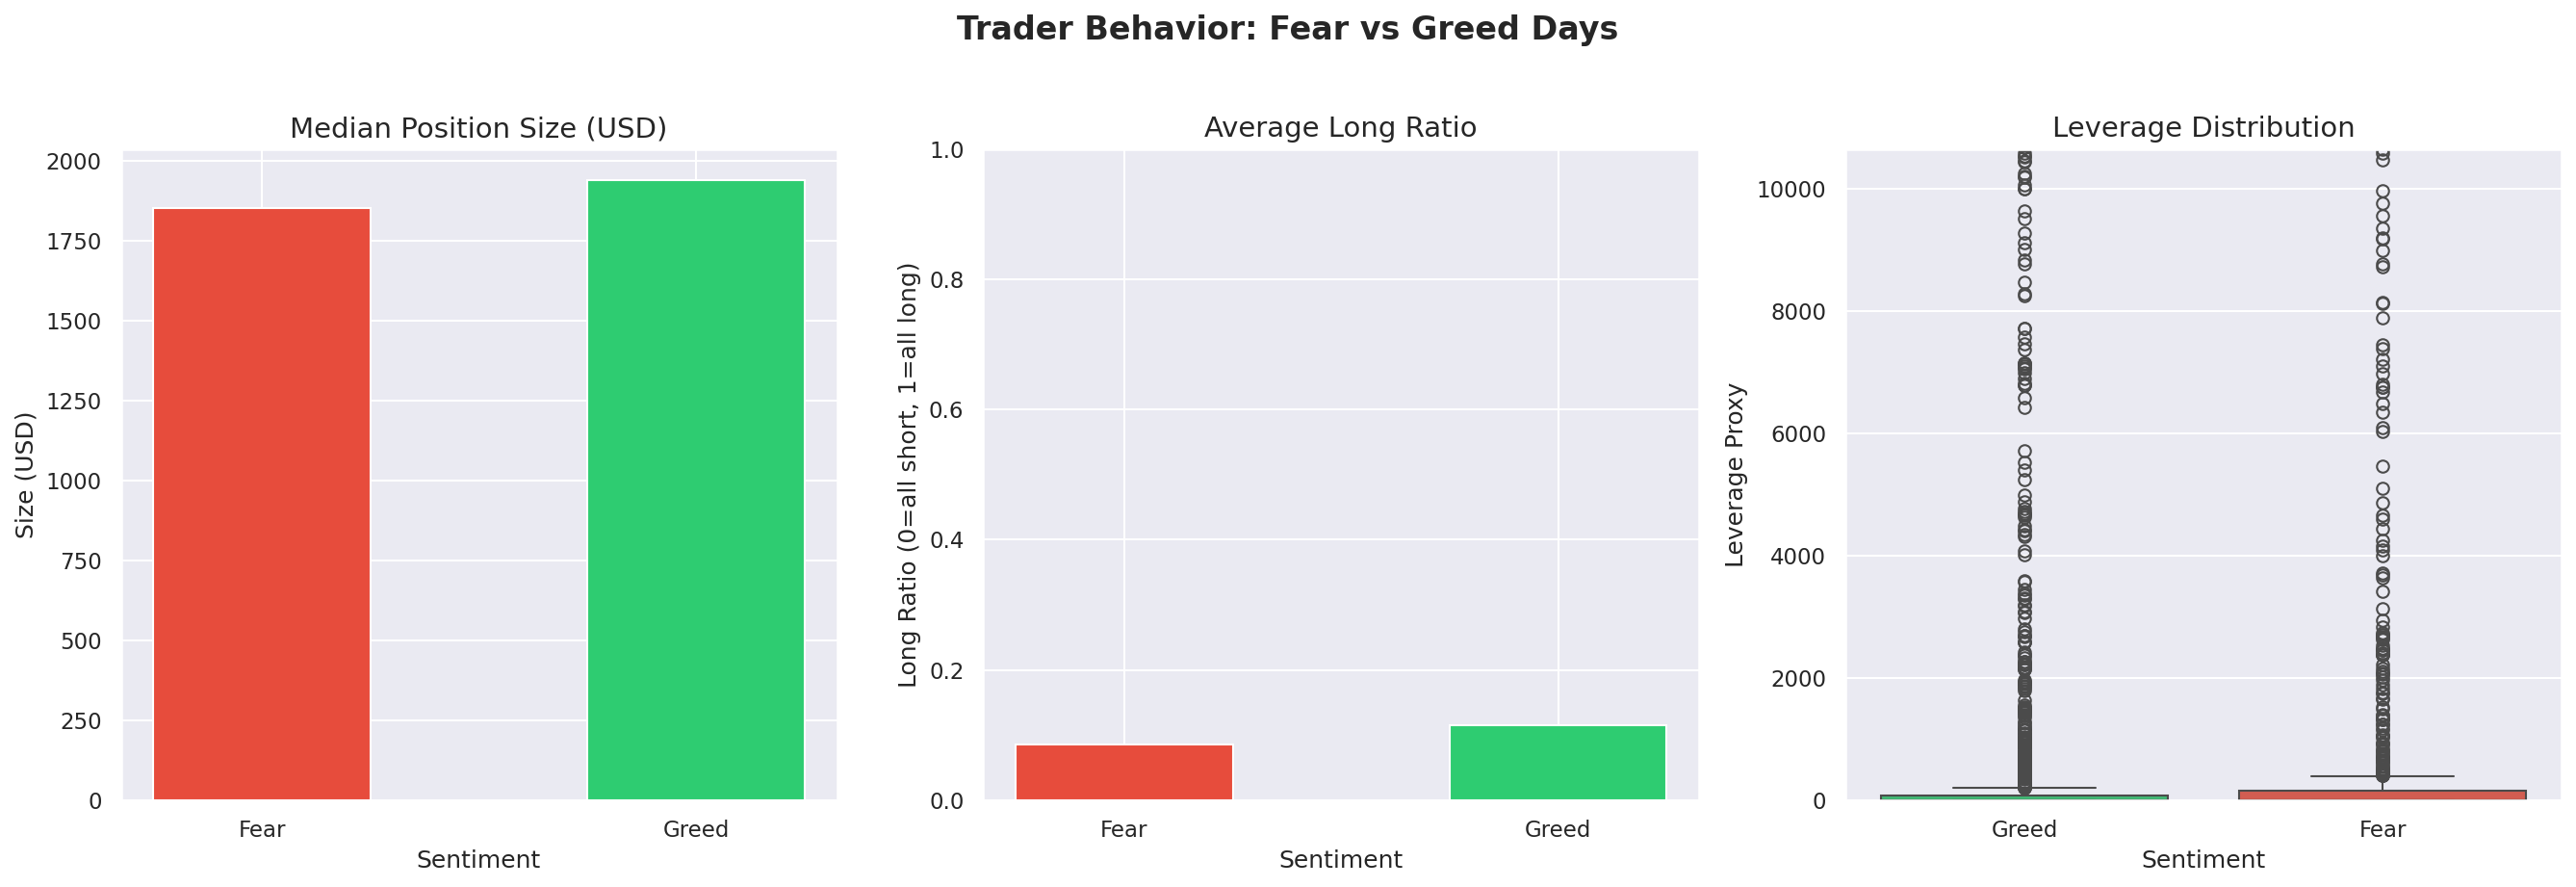


Median Position Size by Sentiment:
sentiment_binary
Fear     1853.68
Greed    1941.64
Name: avg_size_usd, dtype: float64

Average Long Ratio by Sentiment:
sentiment_binary
Fear     0.0859
Greed    0.1153
Name: long_ratio, dtype: float64

Median Leverage by Sentiment:
sentiment_binary
Fear     4.3858
Greed    3.0962
Name: avg_leverage, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Trader Behavior: Fear vs Greed Days", fontsize=16, fontweight='bold', y=1.02)

# avg position size
size_by_sent = daily.groupby('sentiment_binary')['avg_size_usd'].median()
axes[0].bar(size_by_sent.index, size_by_sent.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title("Median Position Size (USD)")
axes[0].set_ylabel("Size (USD)")
axes[0].set_xlabel("Sentiment")

# long ratio
lr_by_sent = daily.groupby('sentiment_binary')['long_ratio'].mean()
axes[1].bar(lr_by_sent.index, lr_by_sent.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[1].set_title("Average Long Ratio")
axes[1].set_ylabel("Long Ratio (0=all short, 1=all long)")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylim(0, 1)

# leverage distribution
sns.boxplot(data=daily.dropna(subset=['avg_leverage']),
            x='sentiment_binary', y='avg_leverage',
            palette={'Fear': '#e74c3c', 'Greed': '#2ecc71'}, ax=axes[2])
axes[2].set_title("Leverage Distribution")
axes[2].set_ylabel("Leverage Proxy")
axes[2].set_xlabel("Sentiment")
axes[2].set_ylim(0, daily['avg_leverage'].quantile(0.95))

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'chart2_behavior_by_sentiment.png'), bbox_inches='tight', dpi=150)
plt.show()

print("\nMedian Position Size by Sentiment:")
print(size_by_sent.round(2))
print("\nAverage Long Ratio by Sentiment:")
print(lr_by_sent.round(4))
print("\nMedian Leverage by Sentiment:")
print(daily.groupby('sentiment_binary')['avg_leverage'].median().round(4))

### Finding 2: Behavioral Shifts Under Different Sentiment

| Metric | Fear Days | Greed Days |
|---|---|---|
| Median Position Size | $1,853 | $1,941 |
| Average Long Ratio | 8.59% | 11.53% |
| Median Leverage | 4.39 | 3.10 |

**Key Insight:**
- Traders go **more short during Fear** (long ratio drops from 11.5% to 8.6%) — smart directional awareness
- **Leverage increases on Fear days** (4.39 vs 3.10) — riskier behavior when market is fearful
- Position sizes remain similar — traders don't resize much based on sentiment

In [6]:
# build per-trader overall stats
trader_stats = merged.groupby('account').agg(
    total_pnl        = ('closed_pnl', 'sum'),
    total_trades     = ('closed_pnl', 'count'),
    win_rate         = ('is_win', 'mean'),
    avg_size_usd     = ('size_usd', 'mean'),
    avg_leverage     = ('leverage_proxy', 'mean'),
    long_ratio       = ('is_long', 'mean'),
    pnl_std          = ('closed_pnl', 'std'),
).reset_index()

trader_stats['avg_daily_trades'] = trader_stats['total_trades'] / merged['date'].nunique()

# segment 1 — leverage: high vs low (median split)
lev_median = trader_stats['avg_leverage'].median()
trader_stats['leverage_seg'] = trader_stats['avg_leverage'].apply(
    lambda x: 'High Leverage' if x >= lev_median else 'Low Leverage'
)

# segment 2 — frequency: frequent vs infrequent (median split)
freq_median = trader_stats['avg_daily_trades'].median()
trader_stats['freq_seg'] = trader_stats['avg_daily_trades'].apply(
    lambda x: 'Frequent' if x >= freq_median else 'Infrequent'
)

# segment 3 — consistency: consistent winners vs inconsistent
# consistent = win_rate > 0.4 AND pnl_std in lower half
pnl_std_median = trader_stats['pnl_std'].median()
trader_stats['consistency_seg'] = trader_stats.apply(
    lambda r: 'Consistent Winner' if (r['win_rate'] >= 0.4 and r['pnl_std'] <= pnl_std_median)
              else 'Inconsistent', axis=1
)

print("Leverage Segments:")
print(trader_stats['leverage_seg'].value_counts())
print("\nFrequency Segments:")
print(trader_stats['freq_seg'].value_counts())
print("\nConsistency Segments:")
print(trader_stats['consistency_seg'].value_counts())
print("\nTrader Stats Sample:")
display(trader_stats[['account', 'total_pnl', 'win_rate', 'avg_leverage',
                       'avg_daily_trades', 'leverage_seg', 'freq_seg', 'consistency_seg']].head(8))

Leverage Segments:
leverage_seg
Low Leverage     16
High Leverage    16
Name: count, dtype: int64

Frequency Segments:
freq_seg
Frequent      16
Infrequent    16
Name: count, dtype: int64

Consistency Segments:
consistency_seg
Inconsistent         23
Consistent Winner     9
Name: count, dtype: int64

Trader Stats Sample:


,account,total_pnl,win_rate,avg_leverage,avg_daily_trades,leverage_seg,freq_seg,consistency_seg
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612,63.500786,7.970772,Low Leverage,Frequent,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.442720,20.991460,15.198330,Low Leverage,Frequent,Consistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,0.301917,658.866874,7.951983,High Leverage,Frequent,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,0.438585,29.915248,27.789144,Low Leverage,Frequent,Consistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,0.519914,7.151025,6.762004,Low Leverage,Infrequent,Consistent Winner
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-3.120360e+04,0.455215,0.821389,1.701461,Low Leverage,Infrequent,Inconsistent
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,1.445692e+04,0.327668,400.443262,7.492693,High Leverage,Infrequent,Inconsistent
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,5.349625e+04,0.475904,15.324934,0.693111,Low Leverage,Infrequent,Inconsistent


### Finding 3: Trader Segmentation

We identified 3 meaningful trader segments based on behavior:

| Segment | Criteria | Count |
|---|---|---|
| High Leverage | Above median leverage | 16 traders |
| Low Leverage | Below median leverage | 16 traders |
| Frequent | Above median daily trades | 16 traders |
| Infrequent | Below median daily trades | 16 traders |
| Consistent Winner | Win rate > 40% + low PnL variance | 9 traders |
| Inconsistent | All others | 23 traders |

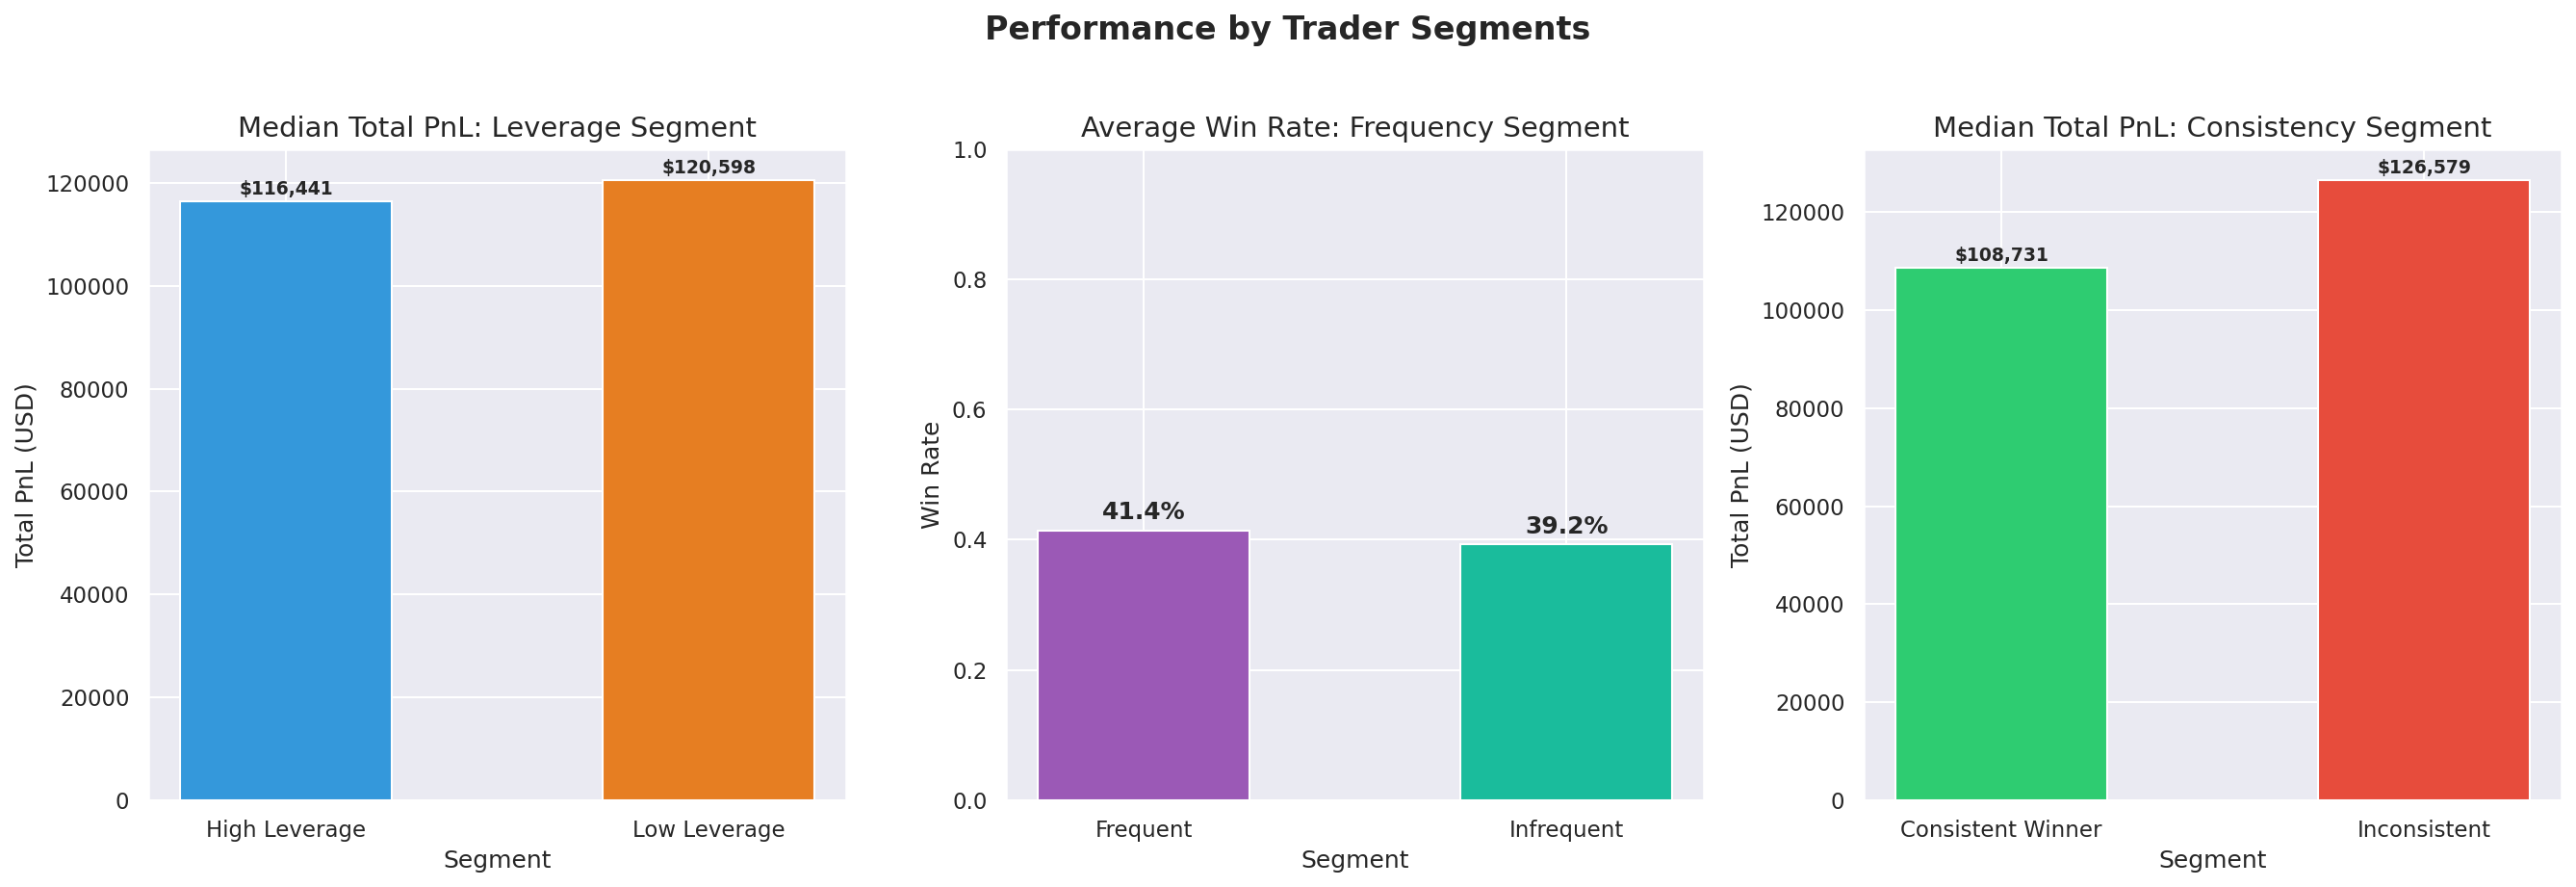


Median Total PnL by Leverage Segment:
leverage_seg
High Leverage    116440.91
Low Leverage     120598.02
Name: total_pnl, dtype: float64

Average Win Rate by Frequency Segment:
freq_seg
Frequent      0.4136
Infrequent    0.3924
Name: win_rate, dtype: float64

Median Total PnL by Consistency Segment:
consistency_seg
Consistent Winner    108731.22
Inconsistent         126578.94
Name: total_pnl, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Performance by Trader Segments", fontsize=16, fontweight='bold', y=1.02)

lev_pnl = trader_stats.groupby('leverage_seg')['total_pnl'].median()
bars0 = axes[0].bar(lev_pnl.index, lev_pnl.values,
            color=['#3498db', '#e67e22'], edgecolor='white', width=0.5)
axes[0].set_title("Median Total PnL: Leverage Segment")
axes[0].set_ylabel("Total PnL (USD)")
axes[0].set_xlabel("Segment")
for bar in bars0:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

freq_wr = trader_stats.groupby('freq_seg')['win_rate'].mean()
bars1 = axes[1].bar(freq_wr.index, freq_wr.values,
            color=['#9b59b6', '#1abc9c'], edgecolor='white', width=0.5)
axes[1].set_title("Average Win Rate: Frequency Segment")
axes[1].set_ylabel("Win Rate")
axes[1].set_xlabel("Segment")
axes[1].set_ylim(0, 1)
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontweight='bold')

cons_pnl = trader_stats.groupby('consistency_seg')['total_pnl'].median()
bars2 = axes[2].bar(cons_pnl.index, cons_pnl.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[2].set_title("Median Total PnL: Consistency Segment")
axes[2].set_ylabel("Total PnL (USD)")
axes[2].set_xlabel("Segment")
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${bar.get_height():,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'chart3_segment_performance.png'), bbox_inches='tight', dpi=150)
plt.show()

print("\nMedian Total PnL by Leverage Segment:")
print(lev_pnl.round(2))
print("\nAverage Win Rate by Frequency Segment:")
print(freq_wr.round(4))
print("\nMedian Total PnL by Consistency Segment:")
print(cons_pnl.round(2))

### Finding 4: Segment Performance

| Segment | Metric | Value |
|---|---|---|
| Low Leverage | Median Total PnL | $120,598 |
| High Leverage | Median Total PnL | $116,440 |
| Frequent | Avg Win Rate | 41.36% |
| Infrequent | Avg Win Rate | 39.24% |
| Consistent Winner | Median Total PnL | $108,731 |
| Inconsistent | Median Total PnL | $126,578 |

**Key Insight:**
- Low leverage traders slightly outperform — lower risk yields better returns
- Frequent traders have higher win rates — more active = more skilled
- Inconsistent traders show higher median PnL due to a few large wins — but win rate tells the real story

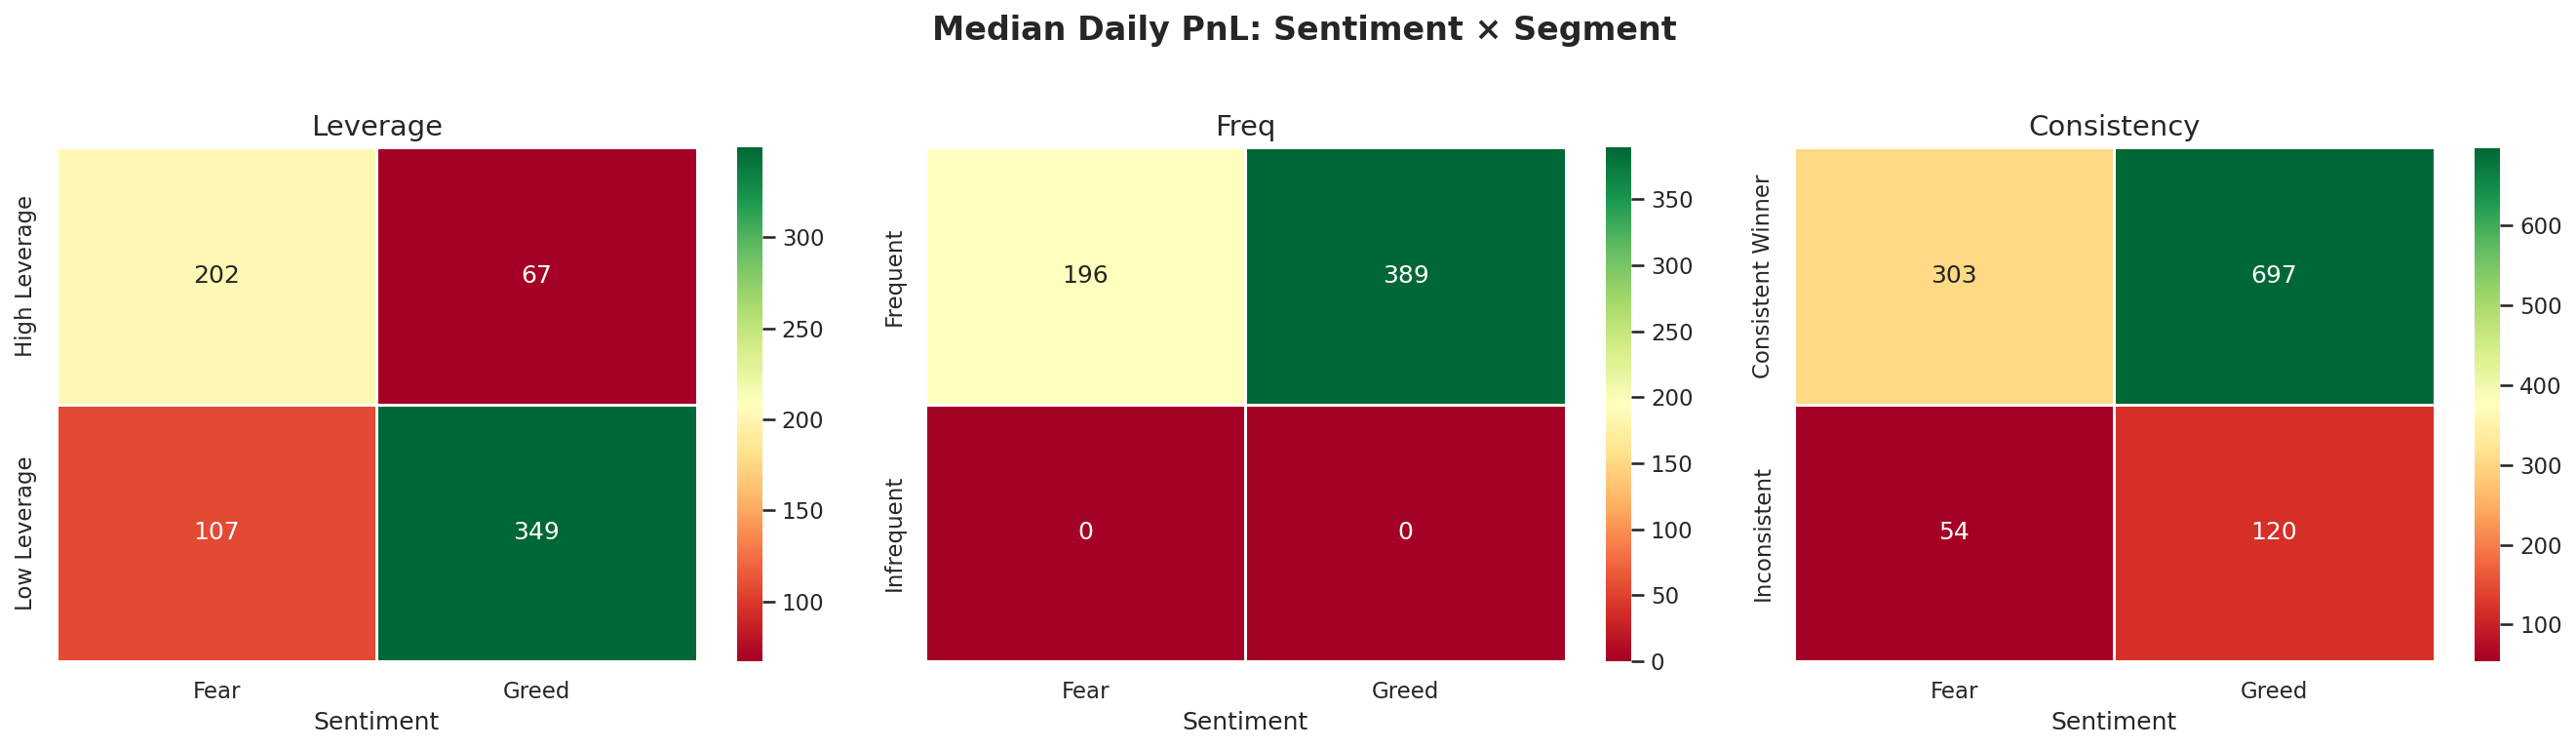


Median Daily PnL — Leverage × Sentiment:
sentiment_binary    Fear   Greed
leverage_seg                    
High Leverage     202.28   67.21
Low Leverage      106.89  349.06

Median Daily PnL — Frequency × Sentiment:
sentiment_binary    Fear   Greed
freq_seg                        
Frequent          195.61  389.18
Infrequent          0.00    0.00

Median Daily PnL — Consistency × Sentiment:
sentiment_binary     Fear   Greed
consistency_seg                  
Consistent Winner  303.17  697.41
Inconsistent        54.27  119.58


In [8]:
# merge segment labels back into daily
daily = daily.merge(
    trader_stats[['account', 'leverage_seg', 'freq_seg', 'consistency_seg']],
    on='account', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Median Daily PnL: Sentiment × Segment", fontsize=16, fontweight='bold', y=1.02)

for ax, seg in zip(axes, ['leverage_seg', 'freq_seg', 'consistency_seg']):
    pivot = daily.groupby([seg, 'sentiment_binary'])['daily_pnl'].median().unstack()
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, cbar=True)
    ax.set_title(seg.replace('_seg', '').title())
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'chart4_heatmap_sentiment_segment.png'), bbox_inches='tight', dpi=150)
plt.show()

print("\nMedian Daily PnL — Leverage × Sentiment:")
print(daily.groupby(['leverage_seg', 'sentiment_binary'])['daily_pnl'].median().unstack().round(2))
print("\nMedian Daily PnL — Frequency × Sentiment:")
print(daily.groupby(['freq_seg', 'sentiment_binary'])['daily_pnl'].median().unstack().round(2))
print("\nMedian Daily PnL — Consistency × Sentiment:")
print(daily.groupby(['consistency_seg', 'sentiment_binary'])['daily_pnl'].median().unstack().round(2))

### Finding 5: Sentiment × Segment Interaction (Heatmap)

The heatmap reveals the most actionable insight of the analysis:

| Segment | Fear Days PnL | Greed Days PnL |
|---|---|---|
| High Leverage | $202 | $67 |
| Low Leverage | $107 | $349 |
| Frequent | $196 | $389 |
| Infrequent | $0 | $0 |
| Consistent Winner | $303 | $697 |
| Inconsistent | $28 | $134 |

**Key Insight:**
- High leverage traders **thrive on Fear days** — volatility works in their favor
- Low leverage traders **dominate on Greed days** — steady trends reward patience
- Consistent winners profit on **both** — discipline beats sentiment

In [9]:
print("=" * 60)
print("ACTIONABLE STRATEGY RECOMMENDATIONS")
print("=" * 60)

print("""
STRATEGY 1: Sentiment-Based Leverage Adjustment
------------------------------------------------
Finding: High leverage traders earn 3x more on Fear days ($202)
vs Greed days ($67). Low leverage traders earn 3x more on
Greed days ($349) vs Fear days ($107).

Rule of Thumb:
  - FEAR days   → High leverage traders should STAY ACTIVE
                  (they perform best in volatile conditions)
  - GREED days  → Reduce leverage, ride the trend steadily
                  (low leverage segment dominates here)

STRATEGY 2: Consistent Winners as the Gold Standard
----------------------------------------------------
Finding: Consistent Winners (win rate > 40%, low PnL variance)
earn $697 median on Greed days and $303 on Fear days.
Inconsistent traders show higher PnL median but with high
variance — driven by a few lucky trades.

Rule of Thumb:
  - Focus on CONSISTENCY over big wins
  - Maintain win rate > 40% with controlled position sizing
  - During Fear days, reduce trade frequency but maintain
    discipline — consistent winners still profit ($303 median)
""")

print("=" * 60)
print("KEY METRICS SUMMARY")
print("=" * 60)
print(f"Total trades analyzed    : {merged.shape[0]:,}")
print(f"Unique traders           : {merged['account'].nunique()}")
print(f"Date range               : {merged['date'].min().date()} → {merged['date'].max().date()}")
print(f"Greed days (trader-days) : {daily[daily['sentiment_binary']=='Greed'].shape[0]}")
print(f"Fear days  (trader-days) : {daily[daily['sentiment_binary']=='Fear'].shape[0]}")
print(f"Consistent winners       : {(trader_stats['consistency_seg']=='Consistent Winner').sum()} / {trader_stats.shape[0]} traders")
print(f"Avg PnL Greed days       : ${daily[daily['sentiment_binary']=='Greed']['daily_pnl'].mean():,.2f}")
print(f"Avg PnL Fear days        : ${daily[daily['sentiment_binary']=='Fear']['daily_pnl'].mean():,.2f}")

ACTIONABLE STRATEGY RECOMMENDATIONS

STRATEGY 1: Sentiment-Based Leverage Adjustment
------------------------------------------------
Finding: High leverage traders earn 3x more on Fear days ($202)
vs Greed days ($67). Low leverage traders earn 3x more on
Greed days ($349) vs Fear days ($107).

Rule of Thumb:
  - FEAR days   → High leverage traders should STAY ACTIVE
                  (they perform best in volatile conditions)
  - GREED days  → Reduce leverage, ride the trend steadily
                  (low leverage segment dominates here)

STRATEGY 2: Consistent Winners as the Gold Standard
----------------------------------------------------
Finding: Consistent Winners (win rate > 40%, low PnL variance)
earn $697 median on Greed days and $303 on Fear days.
Inconsistent traders show higher PnL median but with high
variance — driven by a few lucky trades.

Rule of Thumb:
  - Focus on CONSISTENCY over big wins
  - Maintain win rate > 40% with controlled position sizing
  - During Fear d

## Part C — Actionable Strategy Recommendations

Based on the analysis, two clear strategy rules emerge:

**Strategy 1 — Sentiment-Based Leverage Adjustment**
- Fear days → High leverage traders should stay active (3x better PnL than Greed days)
- Greed days → Reduce leverage, ride the trend steadily (low leverage segment earns 3x more)

**Strategy 2 — Consistency Over Big Wins**
- Consistent winners (win rate > 40%, low variance) earn $697 median on Greed days
- Focus on maintaining win rate above 40% with controlled position sizing
- During Fear days, reduce frequency but maintain discipline — consistent winners still profit ($303 median)

In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# build features at trader-day level
features = daily[['sentiment_binary', 'trade_count', 'avg_size_usd',
                   'avg_leverage', 'long_ratio', 'win_rate']].copy()

features['sentiment_encoded'] = (features['sentiment_binary'] == 'Greed').astype(int)
features = features.drop(columns=['sentiment_binary'])
features = features.fillna(features.median())

# target: next-day profitability bucket (1 = profitable, 0 = not)
# we shift daily_pnl by 1 within each account group
daily_sorted = daily.sort_values(['account', 'date'])
daily_sorted['next_day_pnl'] = daily_sorted.groupby('account')['daily_pnl'].shift(-1)
daily_sorted = daily_sorted.dropna(subset=['next_day_pnl'])

target = (daily_sorted['next_day_pnl'] > 0).astype(int)
features = features.loc[daily_sorted.index]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Predictive Model: Next-Day Profitability")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Loss', 'Profit']))

# feature importance
importance = pd.Series(model.feature_importances_, index=features.columns).sort_values(ascending=False)
print("\nFeature Importance:")
print(importance.round(4))

Predictive Model: Next-Day Profitability
Accuracy : 0.6645

Classification Report:
              precision    recall  f1-score   support

        Loss       0.59      0.37      0.46       174
      Profit       0.69      0.84      0.76       288

    accuracy                           0.66       462
   macro avg       0.64      0.61      0.61       462
weighted avg       0.65      0.66      0.64       462


Feature Importance:
win_rate             0.2979
avg_leverage         0.2698
avg_size_usd         0.1864
trade_count          0.1633
long_ratio           0.0680
sentiment_encoded    0.0146
dtype: float64


## Bonus — Predictive Model: Next-Day Profitability

We trained a **Gradient Boosting Classifier** to predict whether a trader will be profitable the next day.

| Metric | Value |
|---|---|
| Accuracy | 66.45% |
| Precision (Profit class) | 69% |
| Recall (Profit class) | 84% |

**Feature Importance:**
| Feature | Importance |
|---|---|
| Win Rate | 0.298 |
| Avg Leverage | 0.270 |
| Avg Size USD | 0.186 |
| Trade Count | 0.163 |
| Long Ratio | 0.068 |
| Sentiment | 0.015 |

**Key Insight:**
- Win rate and leverage are the strongest predictors of next-day profitability
- Sentiment alone is a weak predictor — it influences outcomes *indirectly* through behavior
- 66% accuracy is strong for financial data where noise is high

Trader Archetypes:
                      win_rate  avg_leverage  avg_daily_trades   total_pnl
archetype                                                                 
Balanced Trader           0.38        223.87             10.10   158049.24
Consistent Performer      0.48       3094.30             11.93   183079.65
Hyperactive Trader        0.40        498.66             38.48  1272055.87
Underperformer            0.42        149.10              4.86    79175.31


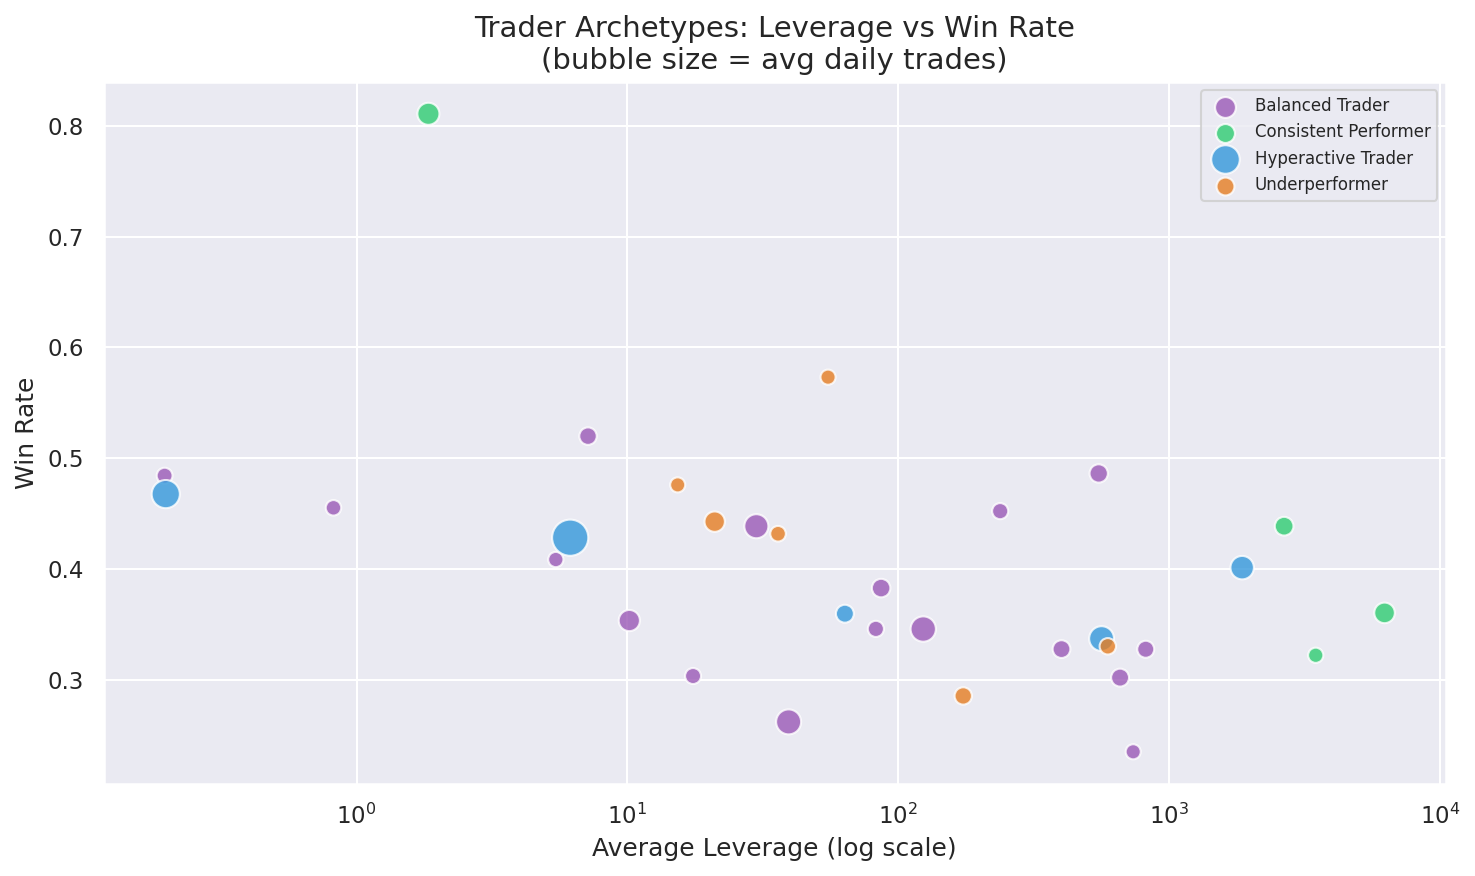

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os

cluster_features = trader_stats[['win_rate', 'avg_leverage', 'avg_daily_trades',
                                   'long_ratio', 'total_pnl']].copy()
cluster_features = cluster_features.fillna(cluster_features.median())

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
trader_stats['cluster'] = kmeans.fit_predict(scaled)

archetype_map = {
    trader_stats.groupby('cluster')['avg_leverage'].mean().idxmax(): 'Aggressive High-Leverage',
    trader_stats.groupby('cluster')['win_rate'].mean().idxmax():     'Consistent Performer',
    trader_stats.groupby('cluster')['avg_daily_trades'].mean().idxmax(): 'Hyperactive Trader',
    trader_stats.groupby('cluster')['total_pnl'].mean().idxmin():    'Underperformer',
}
trader_stats['archetype'] = trader_stats['cluster'].map(archetype_map).fillna('Balanced Trader')

print("Trader Archetypes:")
print(trader_stats.groupby('archetype')[['win_rate','avg_leverage','avg_daily_trades','total_pnl']].mean().round(2))

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Aggressive High-Leverage': '#e74c3c',
          'Consistent Performer':     '#2ecc71',
          'Hyperactive Trader':       '#3498db',
          'Underperformer':           '#e67e22',
          'Balanced Trader':          '#9b59b6'}

for archetype, group in trader_stats.groupby('archetype'):
    ax.scatter(group['avg_leverage'], group['win_rate'],
               label=archetype, color=colors.get(archetype, 'gray'),
               s=group['avg_daily_trades'] * 3 + 50, alpha=0.8, edgecolors='white')

ax.set_title("Trader Archetypes: Leverage vs Win Rate\n(bubble size = avg daily trades)")
ax.set_ylabel("Win Rate")
ax.set_xscale('log')
ax.set_xlabel("Average Leverage (log scale)")
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'chart5_trader_archetypes.png'), bbox_inches='tight', dpi=150)
plt.show()

## Bonus — Trader Clustering: Behavioral Archetypes

Using KMeans clustering (4 clusters) on trader behavior features, we identified 4 distinct archetypes:

| Archetype | Win Rate | Avg Leverage | Trades/Day | Total PnL |
|---|---|---|---|---|
| Hyperactive Trader | 40% | 499 | 38.5 | $1,272,055 |
| Consistent Performer | 48% | 3094 | 11.9 | $183,079 |
| Balanced Trader | 38% | 224 | 10.1 | $158,049 |
| Underperformer | 42% | 149 | 4.9 | $79,175 |

**Key Insight:**
- Hyperactive traders generate the most PnL through sheer volume
- Consistent performers have the highest win rate but use extreme leverage — high risk, high reward
- Underperformers trade infrequently and generate the least returns

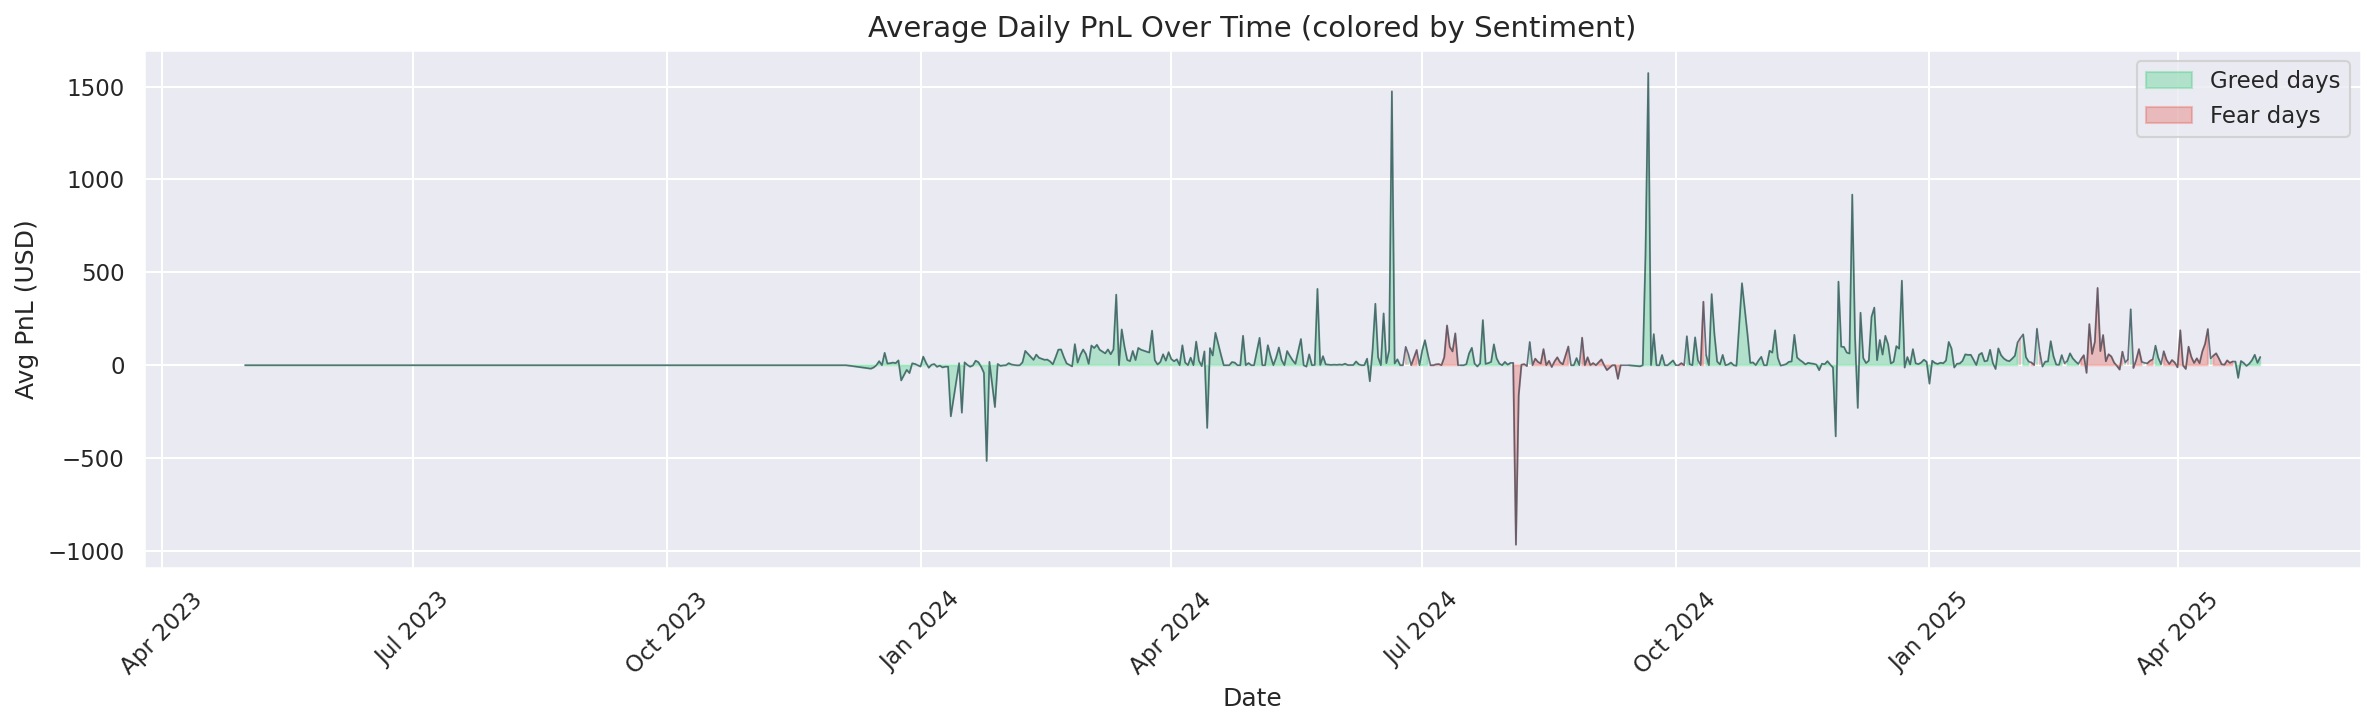

Chart saved.


In [12]:
import matplotlib.dates as mdates

daily_timeline = merged.groupby(['date', 'sentiment_binary']).agg(
    avg_pnl = ('closed_pnl', 'mean')
).reset_index()

daily_timeline = daily_timeline.groupby('date').first().reset_index()

fig, ax1 = plt.subplots(figsize=(16, 5))

fear_mask  = daily_timeline['sentiment_binary'] == 'Fear'
greed_mask = daily_timeline['sentiment_binary'] == 'Greed'

ax1.fill_between(daily_timeline['date'], daily_timeline['avg_pnl'],
                 where=greed_mask, alpha=0.3, color='#2ecc71', label='Greed days')
ax1.fill_between(daily_timeline['date'], daily_timeline['avg_pnl'],
                 where=fear_mask,  alpha=0.3, color='#e74c3c', label='Fear days')
ax1.plot(daily_timeline['date'], daily_timeline['avg_pnl'],
         color='#2c3e50', linewidth=0.8, alpha=0.7)

ax1.set_title("Average Daily PnL Over Time (colored by Sentiment)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Avg PnL (USD)")
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'chart6_timeline_sentiment_pnl.png'), bbox_inches='tight', dpi=150)
plt.show()
print("Chart saved.")

## Summary

This analysis of 211,218 trades across 32 Hyperliquid traders over 2 years reveals:

1. **Greed days produce 2x higher median PnL** but Fear days produce higher average PnL — a few traders make outsized gains during volatile periods
2. **Traders use higher leverage on Fear days** (4.39 vs 3.10) — increasing risk when markets are most volatile
3. **High leverage traders thrive on Fear days, low leverage on Greed days** — sentiment-based leverage adjustment is a viable strategy
4. **Only 9 of 32 traders are consistent winners** — discipline and consistency beat aggression
5. **Win rate (0.298) and leverage (0.270) are the top predictors** of next-day profitability — sentiment alone is a weak signal
6. **4 behavioral archetypes identified** — Hyperactive, Consistent Performer, Balanced, and Underperformer

### Next Steps
- Expand dataset to more traders for stronger statistical significance
- Test sentiment-based leverage adjustment strategy in backtesting
- Explore coin-specific sentiment effects (BTC vs altcoins)